## Results for Berlin

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
import os
from sqlalchemy import create_engine,text
db_url = (
    f"postgresql://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

engine = create_engine(db_url)


In [3]:
line_stations_gdf = gpd.GeoDataFrame.from_file("/home/jmartinez/Documents/bike_project/src/python/src/bike_project/validation/Berlin/berlin_stations_line_ref.geojson")
line_stations_gdf.to_postgis("counting_stations_lines_berlin",engine, if_exists="replace")

In [4]:
point_stations_gdf = gpd.GeoDataFrame.from_file("/home/jmartinez/Documents/bike_project/src/python/src/bike_project/validation/Berlin/berlin_stations_ref_clean.geojson")
count_stations_gdf = gpd.GeoDataFrame.from_file("/home/jmartinez/Documents/bike_project/src/python/src/bike_project/validation/Berlin/berlin_stations_count.csv")
count_stations_gdf["date"] = pd.to_datetime(count_stations_gdf["time"]).dt.date
count_stations_gdf["count"] = count_stations_gdf["count"].replace('','0').astype(float)
daily_df = count_stations_gdf[["id","date","count"]].groupby(["id","date"],as_index=False).sum()
num_days_df = daily_df[["id","date"]].groupby(["id"],as_index=False).count().rename(columns={"date":"num_days"})
total_count_df = daily_df[["id","count"]].groupby(["id"],as_index=False).sum()
average_daily_df = pd.merge(total_count_df,num_days_df)
average_daily_df["count_aadt"] = average_daily_df["count"] / average_daily_df["num_days"]
final_merged_gdf = point_stations_gdf[["id","geometry"]].merge(average_daily_df,how="inner")
final_merged_gdf.to_postgis("counting_stations_points_berlin",engine, if_exists="replace")

In [5]:
with engine.begin() as conn:
    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN IF NOT EXISTS count_stations INTEGER,
    ADD COLUMN IF NOT EXISTS num_points INTEGER;"""))

    conn.execute(text("""WITH results AS (
    SELECT l.id as id, l.geometry as geom, SUM(count_aadt) as count_stations, count(*) as num_points FROM
    (counting_stations_lines_berlin l
    INNER JOIN counting_stations_points_berlin p
    ON ST_Distance(l.geometry::geography,p.geometry::geography) < 100)
    GROUP BY l.id,l.geometry
    )
    UPDATE counting_stations_lines_berlin s
    SET num_points = results.num_points,count_stations = results.count_stations
    FROM results
    WHERE s.id = results.id;
    """))



In [6]:
with engine.begin() as conn:
    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    DROP COLUMN IF EXISTS count_base;"""))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN count_base INTEGER;

    WITH counts_base AS (
        SELECT g.id as id, sum(l.count_occ) as count_base
        FROM counting_stations_lines_berlin g
        INNER JOIN
        results_berlin_base_betweenness l
        ON ST_Intersects(g.geometry, l.geom)
        GROUP BY g.id
    )
    UPDATE counting_stations_lines_berlin h
    SET count_base = counts_base.count_base
    FROM counts_base
    WHERE h.id = counts_base.id ;

    """))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    DROP COLUMN IF EXISTS count_sim;"""))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN count_sim INTEGER;

    WITH counts_sim AS (
        SELECT g.id as id, sum(l.count_occ) as count_sim
        FROM counting_stations_lines_berlin g
        INNER JOIN
        results_berlin_final l
        ON ST_Intersects(g.geometry, l.geom)
        GROUP BY g.id
    )
    UPDATE counting_stations_lines_berlin h
    SET count_sim = counts_sim.count_sim
    FROM counts_sim
    WHERE h.id = counts_sim.id ;

"""))


In [7]:
with engine.begin() as conn:
    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    DROP COLUMN IF EXISTS count_base_pois;"""))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN count_base_pois INTEGER;

    WITH counts_base AS (
        SELECT g.id as id, sum(l.count_occ) as count_base_pois
        FROM counting_stations_lines_berlin g
        INNER JOIN
        results_berlin_base_pois l
        ON ST_Intersects(g.geometry, l.geom)
        GROUP BY g.id
    )
    UPDATE counting_stations_lines_berlin h
    SET count_base_pois = counts_base.count_base_pois
    FROM counts_base
    WHERE h.id = counts_base.id ;

    """))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    DROP COLUMN IF EXISTS count_base_nrd;"""))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN count_base_nrd INTEGER;

    WITH counts_sim AS (
        SELECT g.id as id, sum(l.count_occ) as count_base_nrd
        FROM counting_stations_lines_berlin g
        INNER JOIN
        results_berlin_base_non_random_des l
        ON ST_Intersects(g.geometry, l.geom)
        GROUP BY g.id
    )
    UPDATE counting_stations_lines_berlin h
    SET count_base_nrd = counts_sim.count_base_nrd
    FROM counts_sim
    WHERE h.id = counts_sim.id ;

"""))

In [8]:
with engine.begin() as conn:
    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    DROP COLUMN IF EXISTS count_base_dist;"""))

    conn.execute(text("""
    ALTER TABLE counting_stations_lines_berlin
    ADD COLUMN count_base_dist INTEGER;

    WITH counts_base AS (
        SELECT g.id as id, sum(l.count_occ) as count_base_dist
        FROM counting_stations_lines_berlin g
        INNER JOIN
        results_berlin_base_dist l
        ON ST_Intersects(g.geometry, l.geom)
        GROUP BY g.id
    )
    UPDATE counting_stations_lines_berlin h
    SET count_base_dist = counts_base.count_base_dist
    FROM counts_base
    WHERE h.id = counts_base.id ;

    """))

In [9]:
query = """SELECT * FROM counting_stations_lines_berlin"""

berlin_gdf = gpd.GeoDataFrame.from_postgis(query, engine, geom_col="geometry")
berlin_gdf

,id,geometry,count_stations,num_points,count_base,count_sim,count_base_pois,count_base_nrd,count_base_dist
0,1,"MULTILINESTRING ((13.33307 52.48813, 13.33319 ...",1673,1,57,143,84,132,154
1,2,"MULTILINESTRING ((13.32671 52.51324, 13.32682 ...",4216,2,4120,1175,2732,5177,1436
2,3,"MULTILINESTRING ((13.36979 52.48815, 13.36978 ...",3272,1,264,573,300,676,504
3,4,"MULTILINESTRING ((13.37331 52.49229, 13.37324 ...",5464,2,7099,2686,5437,10807,3048
4,5,"MULTILINESTRING ((13.3724 52.52753, 13.37254 5...",4509,2,3959,1893,2889,5591,1988
5,6,"MULTILINESTRING ((13.35218 52.53964, 13.35222 ...",1240,1,33,88,19,85,67
6,7,"MULTILINESTRING ((13.41233 52.53154, 13.41244 ...",2886,1,1450,1011,974,2459,951
7,8,"MULTILINESTRING ((13.41205 52.54304, 13.41215 ...",2083,1,1721,1027,2143,2773,1204
8,9,"MULTILINESTRING ((13.41749 52.52184, 13.41743 ...",2896,1,1586,701,1402,2381,657
9,10,"MULTILINESTRING ((13.42617 52.51901, 13.42614 ...",2310,1,1207,452,710,1790,456


In [10]:
berlin_gdf["rank_real"] = berlin_gdf["count_stations"].rank(ascending=False)
berlin_gdf["rank_base"] = berlin_gdf["count_base"].rank(ascending=False)
berlin_gdf["rank_base_pois"] = berlin_gdf["count_base_pois"].rank(ascending=False)
berlin_gdf["rank_base_nrd"] = berlin_gdf["count_base_nrd"].rank(ascending=False)

berlin_gdf["rank_base_dist"] = berlin_gdf["count_base_dist"].rank(ascending=False)

berlin_gdf["rank_sim"] = berlin_gdf["count_sim"].rank(ascending=False)
berlin_gdf["rank_diff"] = berlin_gdf["rank_real"] - berlin_gdf["rank_sim"]

berlin_gdf

,id,geometry,count_stations,num_points,count_base,count_sim,count_base_pois,count_base_nrd,count_base_dist,rank_real,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim,rank_diff
0,1,"MULTILINESTRING ((13.33307 52.48813, 13.33319 ...",1673,1,57,143,84,132,154,16.0,16.0,17.0,17.0,16.0,17.0,-1.0
1,2,"MULTILINESTRING ((13.32671 52.51324, 13.32682 ...",4216,2,4120,1175,2732,5177,1436,8.0,3.0,4.0,4.0,6.0,7.0,1.0
2,3,"MULTILINESTRING ((13.36979 52.48815, 13.36978 ...",3272,1,264,573,300,676,504,9.0,15.0,13.0,13.0,11.0,11.0,-2.0
3,4,"MULTILINESTRING ((13.37331 52.49229, 13.37324 ...",5464,2,7099,2686,5437,10807,3048,3.0,2.0,2.0,2.0,2.0,2.0,1.0
4,5,"MULTILINESTRING ((13.3724 52.52753, 13.37254 5...",4509,2,3959,1893,2889,5591,1988,7.0,4.0,3.0,3.0,3.0,3.0,4.0
5,6,"MULTILINESTRING ((13.35218 52.53964, 13.35222 ...",1240,1,33,88,19,85,67,18.0,18.0,18.0,18.0,18.0,18.0,0.0
6,7,"MULTILINESTRING ((13.41233 52.53154, 13.41244 ...",2886,1,1450,1011,974,2459,951,11.0,10.0,10.0,9.0,9.0,9.0,2.0
7,8,"MULTILINESTRING ((13.41205 52.54304, 13.41215 ...",2083,1,1721,1027,2143,2773,1204,15.0,8.0,7.0,8.0,8.0,8.0,7.0
8,9,"MULTILINESTRING ((13.41749 52.52184, 13.41743 ...",2896,1,1586,701,1402,2381,657,10.0,9.0,9.0,10.0,10.0,10.0,0.0
9,10,"MULTILINESTRING ((13.42617 52.51901, 13.42614 ...",2310,1,1207,452,710,1790,456,14.0,11.0,12.0,11.0,12.0,12.0,2.0


In [11]:
berlin_gdf[["count_stations","count_base","count_base_pois","count_base_nrd",
         "count_base_dist","count_sim"]].corr()

,count_stations,count_base,count_base_pois,count_base_nrd,count_base_dist,count_sim
count_stations,1.000000,0.775721,0.807831,0.830215,0.878934,0.896280
count_base,0.775721,1.000000,0.982712,0.988034,0.943681,0.916674
count_base_pois,0.807831,0.982712,1.000000,0.993389,0.976015,0.955941
count_base_nrd,0.830215,0.988034,0.993389,1.000000,0.979311,0.962076
count_base_dist,0.878934,0.943681,0.976015,0.979311,1.000000,0.994440
count_sim,0.896280,0.916674,0.955941,0.962076,0.994440,1.000000


In [12]:
berlin_gdf[["rank_real","rank_base","rank_base_pois","rank_base_nrd",
         "rank_base_dist","rank_sim"]].corr()

,rank_real,rank_base,rank_base_pois,rank_base_nrd,rank_base_dist,rank_sim
rank_real,1.000000,0.682147,0.686275,0.715170,0.735810,0.770898
rank_base,0.682147,1.000000,0.985552,0.985552,0.962848,0.950464
rank_base_pois,0.686275,0.985552,1.000000,0.991744,0.977296,0.969040
rank_base_nrd,0.715170,0.985552,0.991744,1.000000,0.985552,0.979360
rank_base_dist,0.735810,0.962848,0.977296,0.985552,1.000000,0.993808
rank_sim,0.770898,0.950464,0.969040,0.979360,0.993808,1.000000


rank_base         0.001817
rank_base_pois    0.001661
rank_base_nrd     0.000849
rank_base_dist    0.000500
rank_sim          0.000181
Name: rank_real, dtype: float64


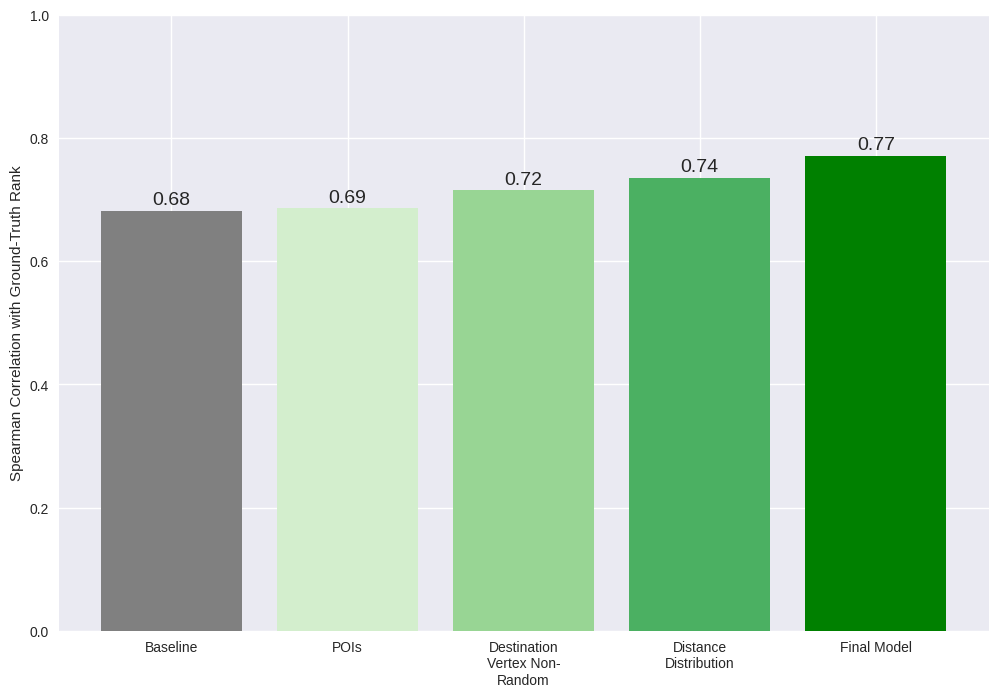

In [ ]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr, kendalltau

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    berlin_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]
    .corr()["rank_real"]
    .drop("rank_real")
)


rank_df = berlin_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]


cols = rank_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = spearmanr(rank_df[c1], rank_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["rank_real"]
    .drop("rank_real"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)


for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Spearman Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/berlin_spearman")

import tikzplotlib


tikzplotlib.save("figures/berlin_spearman.tex")

rank_base         0.003935
rank_base_pois    0.002244
rank_base_nrd     0.002244
rank_base_dist    0.000897
rank_sim          0.000325
Name: rank_real, dtype: float64


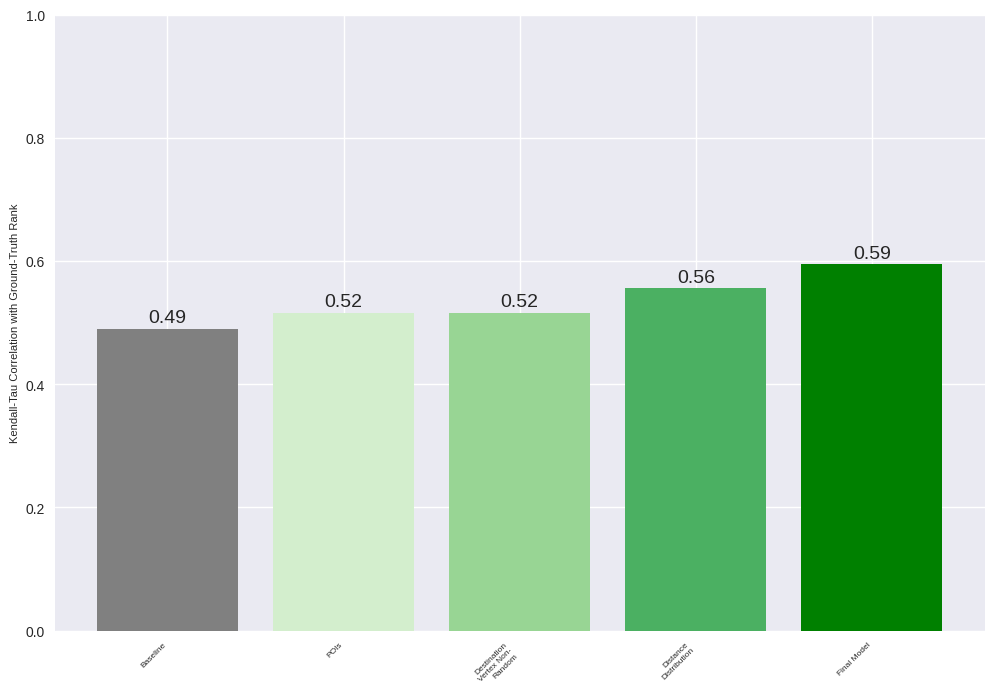

In [14]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    berlin_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]
    .corr(method="kendall")["rank_real"]
    .drop("rank_real")
)

rank_df = berlin_gdf[["rank_real", "rank_base", "rank_base_pois","rank_base_nrd","rank_base_dist","rank_sim"]]


cols = rank_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = kendalltau(rank_df[c1], rank_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["rank_real"]
    .drop("rank_real"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center",fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Kendall-Tau Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/berlin_kendalltau")

import tikzplotlib

tikzplotlib.save("figures/berlin_kendalltau.tex")

count_base         1.548330e-04
count_base_pois    5.016567e-05
count_base_nrd     2.008136e-05
count_base_dist    1.576689e-06
count_sim          4.842189e-07
Name: count_stations, dtype: float64


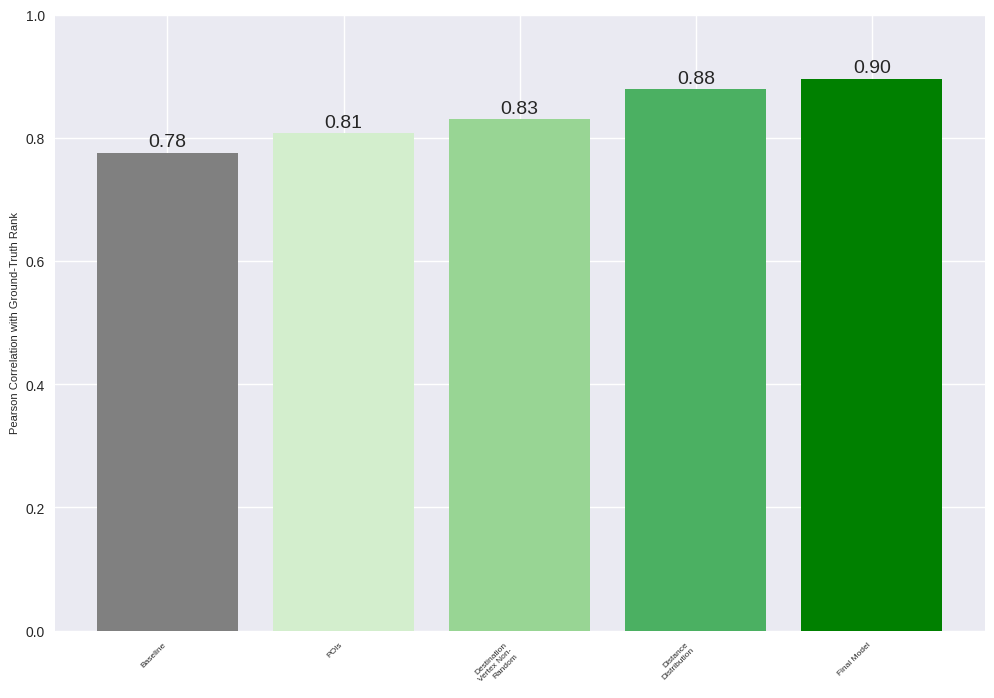

In [16]:
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

plt.style.use('seaborn-v0_8')

corrs = (
    berlin_gdf[["count_stations", "count_base", "count_base_pois","count_base_nrd","count_base_dist","count_sim"]]
    .corr(method="pearson")["count_stations"]
    .drop("count_stations")
)

count_df = berlin_gdf[["count_stations", "count_base", "count_base_pois","count_base_nrd","count_base_dist","count_sim"]]


cols = count_df.columns

corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for c1 in cols:
    for c2 in cols:
        tau, pval = pearsonr(count_df[c1], count_df[c2])

        corr_matrix.loc[c1, c2] = tau
        p_matrix.loc[c1, c2] = pval

pval_df = pd.DataFrame(p_matrix, index=cols,columns=cols)



print(pval_df["count_stations"]
    .drop("count_stations"))


labels = ["Baseline", "POIs", "Destination Vertex Non-Random","Distance Distribution","Final Model"]
wrapped_labels = [textwrap.fill(label, 14) for label in labels]

middle_colors = plt.cm.Greens(np.linspace(0.2, 0.6, 3))

colors = (
    ["gray"] +                    
    list(middle_colors) +         
    ["green", "#6D3B07", "#EC1B2D"]    
)
plt.bar(
    x=wrapped_labels,
    height=corrs.values, color=colors)

for i, v in enumerate(corrs.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center",fontsize=14)

plt.ylim(0, 1)
plt.ylabel("Pearson Correlation with Ground-Truth Rank", fontsize = 8)
# plt.xlabel("Method")
plt.xticks(rotation=45, ha="right", fontsize=6)

plt.savefig("figures/berlin_pearson")

import tikzplotlib

tikzplotlib.save("figures/berlin_pearson.tex")